##  Make a connection to the database (it is the same as the previous day).

In [1]:
import pandas as pd
import sqlite3

from matplotlib.pyplot import xticks

conn = sqlite3.connect('../data/checking-logs.sqlite')

## Run a query that gets the datetime from the pageviews table, selecting only users and not admins. 


In [2]:
query = """
SELECT datetime
FROM pageviews 
WHERE uid NOT LIKE "admin_%"
"""
datetime = pd.read_sql_query(query, conn)
datetime['datetime'] = pd.to_datetime(datetime['datetime'])
datetime

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


## Using Pandas, create a new dataframe where the visits are counted and grouped by date.

In [3]:
group_by_date = datetime.groupby(datetime['datetime'].dt.date).size()
group_by_date

datetime
2020-04-17      1
2020-04-18     23
2020-04-19     15
2020-04-21      3
2020-04-22      1
2020-04-23      5
2020-04-25      1
2020-04-26      8
2020-04-28      2
2020-04-29      4
2020-04-30      9
2020-05-01      3
2020-05-02      6
2020-05-03     19
2020-05-04      1
2020-05-05      1
2020-05-06      3
2020-05-07      2
2020-05-08     48
2020-05-09     19
2020-05-10    110
2020-05-11    200
2020-05-12     85
2020-05-13    102
2020-05-14    187
2020-05-15     29
2020-05-16      4
2020-05-17      9
2020-05-18     51
2020-05-19     11
2020-05-20     12
2020-05-21     11
2020-05-22      2
dtype: int64

## Using the Pandas method .plot(), create a graph:
The size of the font should be 8.
The size of the figure is (15, 8).
The graph must have the title "Views per Day".
Notice the rotation of the xticks on the graph below.

<Axes: title={'center': 'Views per Day'}, xlabel='datetime'>

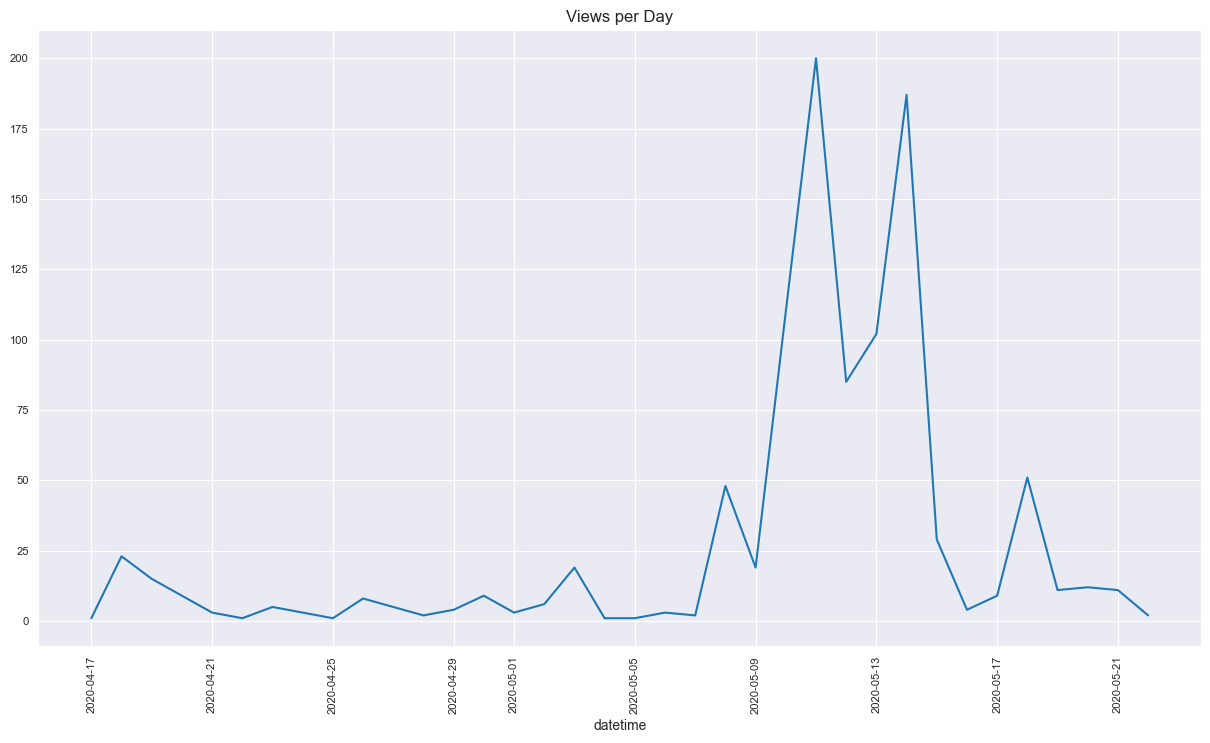

In [4]:
group_by_date.plot(figsize=(15,8), title = "Views per Day", fontsize=8, rot=90)

## Close the connection to the database.


In [5]:
conn.close()